<a href="https://colab.research.google.com/github/Zeldano118/duolingo-sentiment-analysis/blob/main/notebooks/01_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Collection
**Project:** Duolingo Sentiment Analysis  
**Source:** Google Play Store (`com.duolingo`)  
**Goal:** Scrape 1,000 English-language reviews and save them as a raw CSV file.

---

## What This Notebook Does

| Step | Action | Output |
|---|---|---|
| 1 | Install & import dependencies | — |
| 2 | Set up folder structure | `data/raw/`, `data/processed/`, `data/labeled/` |
| 3 | Scrape reviews from Google Play | — |
| 4 | Save raw data | `data/raw/duolingo_raw.csv` |
| 5 | Preview & basic inspection | — |

---

## Why Google Play Store?

Google Play reviews are publicly accessible, come with a built-in star rating (1–5),
and require no API key or paid access. This makes them ideal for sentiment analysis:
the rating acts as a natural sentiment signal that we can use for labeling later.

> **Note:** This notebook only handles data collection. No cleaning or labeling happens here.
> Raw data is saved as-is so that the full original text is preserved for the next stage.

---
## Step 1 — Install & Import Dependencies

In [ ]:
# google-play-scraper: fetches reviews directly from the Play Store
!pip install google-play-scraper -q

print("✅ Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 746.3 kB/s eta 0:00:00
✅ Installation complete.


In [ ]:
import os
import pandas as pd
from google_play_scraper import reviews, Sort

print("✅ Imports successful.")

✅ Imports successful.


---
## Step 2 — Set Up Folder Structure

We create the `data/` subfolders here so every notebook in this project
can reference the same paths consistently.

```
data/
├── raw/          ← hasil scraping (notebook ini)
├── processed/    ← setelah preprocessing (notebook 02)
└── labeled/      ← setelah labeling (notebook 03)
```

> These folders are listed in `.gitignore` — CSV files will not be pushed to GitHub.

In [ ]:
import os

# Create data subdirectories if they don't exist yet
folders = ['data/raw', 'data/processed', 'data/labeled']

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"📁 {folder}")

print("\n✅ Folder structure ready.")

📁 data/raw
📁 data/processed
📁 data/labeled

✅ Folder structure ready.


---
## Step 3 — Scrape Reviews

### Parameters Explained

| Parameter | Value | Reason |
|---|---|---|
| `app_id` | `com.duolingo` | Duolingo's unique Play Store identifier |
| `lang` | `en` | English reviews only |
| `country` | `us` | US store (largest English-language base) |
| `sort` | `Sort.NEWEST` | Most recent reviews first |
| `count` | `1000` | Target number of reviews |

### Why `Sort.NEWEST`?
Recent reviews reflect the current version of the app. Sorting by relevance
or rating can introduce bias (e.g., only showing extreme opinions).

> **Heads up:** Scraping 1,000 reviews may take 1–3 minutes. This is normal —
> the scraper makes multiple paginated requests to the Play Store.

In [ ]:
APP_ID  = 'com.duolingo'
LANG    = 'en'
COUNTRY = 'us'
COUNT   = 1000

print(f"Scraping {COUNT} reviews for '{APP_ID}'...")
print("This may take a few minutes — please wait.\n")

result, _ = reviews(
    APP_ID,
    lang=LANG,
    country=COUNTRY,
    sort=Sort.NEWEST,
    count=COUNT
)

print(f"✅ Scraping complete. Total reviews fetched: {len(result)}")

Scraping 1000 reviews for 'com.duolingo'...
This may take a few minutes — please wait.

✅ Scraping complete. Total reviews fetched: 1000


---
## Step 4 — Select Columns & Save to CSV

The scraper returns many fields per review. We only keep what's useful:

| Column | Description |
|---|---|
| `reviewId` | Unique identifier for each review |
| `content` | The actual review text |
| `score` | Star rating given by the user (1–5) |
| `thumbsUpCount` | Number of users who liked this review |
| `at` | Date and time the review was posted |

> `score` is especially important — in notebook 03 we will use it to
> automatically assign sentiment labels (negative / neutral / positive).

In [ ]:
# Convert to DataFrame and select relevant columns
df = pd.DataFrame(result)[['reviewId', 'content', 'score', 'thumbsUpCount', 'at']]

# Save raw data — no modifications at this stage
OUTPUT_PATH = 'data/raw/duolingo_raw.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Raw data saved to: {OUTPUT_PATH}")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]} — {list(df.columns)}")

✅ Raw data saved to: data/raw/duolingo_raw.csv
   Rows    : 1000
   Columns : 5 — ['reviewId', 'content', 'score', 'thumbsUpCount', 'at']


---
## Step 5 — Preview & Basic Inspection

Before moving to the next notebook, let's do a quick sanity check:
- Are there any missing values?
- How are star ratings distributed?
- What does the data actually look like?

In [ ]:
# First look at the data
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['at'].min()} → {df['at'].max()}")
print()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Preview first 5 rows
print("Sample data (first 5 rows):")
df.head()

DATASET OVERVIEW
Shape   : 1000 rows × 5 columns
Date range: 2026-05-11 13:47:12 → 2026-05-12 07:20:56

Missing values per column:
reviewId         0
content          0
score            0
thumbsUpCount    0
at               0
dtype: int64

Sample data (first 5 rows):


,reviewId,content,score,thumbsUpCount,at
0,ee4e687b-4dde-4659-b227-35c735e7971e,this app is amazing 😍,5,0,2026-05-12 07:20:56
1,68366eae-b24a-464c-acee-7e796cc57ff5,is good,4,0,2026-05-12 07:20:39
2,472559dd-f606-461e-ac26-6e1581f1cb8d,nice,5,0,2026-05-12 07:20:18
3,2c769e11-41f0-41e3-a80a-1a0722fc359b,very good.,5,0,2026-05-12 07:19:44
4,2cfb8739-b27f-4b9d-bbcd-afbd884613e6,very good👍,5,0,2026-05-12 07:19:26


/tmp/ipykernel_5775/2339191262.py:24: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


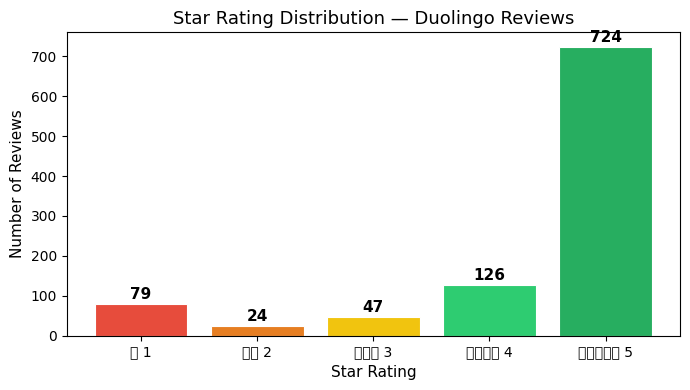


Rating breakdown:
  1 star(s):   79 reviews (7.9%)
  2 star(s):   24 reviews (2.4%)
  3 star(s):   47 reviews (4.7%)
  4 star(s):  126 reviews (12.6%)
  5 star(s):  724 reviews (72.4%)


In [ ]:
import matplotlib.pyplot as plt

# Star rating distribution
rating_counts = df['score'].value_counts().sort_index()

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

plt.figure(figsize=(7, 4))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Star Rating Distribution — Duolingo Reviews', fontsize=13)
plt.xlabel('Star Rating', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)
plt.xticks([1, 2, 3, 4, 5], ['⭐ 1', '⭐⭐ 2', '⭐⭐⭐ 3', '⭐⭐⭐⭐ 4', '⭐⭐⭐⭐⭐ 5'])
plt.tight_layout()
plt.show()

print("\nRating breakdown:")
for score, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"  {score} star(s): {count:>4} reviews ({pct:.1f}%)")

In [ ]:
# Read a few actual reviews per rating to get a feel for the data
print("Sample reviews per star rating:")
print("=" * 55)

for score in [1, 3, 5]:
    sample = df[df['score'] == score]['content'].dropna().iloc[0]
    label_hint = {1: 'likely NEGATIVE', 3: 'likely NEUTRAL', 5: 'likely POSITIVE'}[score]
    print(f"\n⭐ {score} star ({label_hint}):")
    print(f"  \"{sample[:200]}...\"" if len(sample) > 200 else f"  \"{sample}\"")

Sample reviews per star rating:

⭐ 1 star (likely NEGATIVE):
  "I used to like it, I had a 100+ days streak but then I found out most of the team was replaced by ai 👎🏻 I deleted mi account"

⭐ 3 star (likely NEUTRAL):
  "please add Urdu option too so we'll learn languages from Urdu"

⭐ 5 star (likely POSITIVE):
  "this app is amazing 😍"


---
## ✅ Notebook Complete

**What we did:**
- Scraped 1,000 English reviews from Duolingo's Play Store page
- Saved the raw data to `data/raw/duolingo_raw.csv`
- Inspected the rating distribution and sampled a few reviews

**What to expect in the data:**
- Play Store reviews tend to be polarized — many 1-star and 5-star, fewer 2–4 star
- Some reviews may be very short (just one word) or contain emojis
- A few `content` values might be empty — we'll handle that in the next notebook

**Next step → `02_preprocessing.ipynb`**  
Clean the raw text: lowercase, remove noise, strip stopwords, apply stemming.